<hr style="border:2px solid #CC00FF"> </hr>
<a><img src="https://www.vhv.rs/dpng/d/313-3134285_logo-de-la-universidad-nacional-de-colombia-png.png" width="100" align="center"></a>
<a><img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" width="100" align="center"></a>
<h1><center>Simulación Avanzada</center></h1>
<h2><center>Tarea 4</center></h2>
<h3><center>Implementación de juegos de azar (parte 3)</center></h3>

<a name="conte"></a>
<hr style="border:2px solid #CC00FF"> </hr>


**Elaborado por:** _Laura Isabel Greiffenstein Moreno_ & _Kevin Ferney Hidalgo Higuita_

**Correos:** _lgreiffenstein@unal.edu.co_ & _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _2026 Marzo 28_

**Fecha última modificación:** _2026 Marzo 28_

Repositorio [GitHub](https://github.com/thepadr30/SimulAva3010192)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*


# Excavación en el Valle de los Reyes

**Objetivo del juego**
El jugador asume el papel de un arqueólogo financiando una expedición. El objetivo es encontrar
reliquias, pesarlas y venderlas al museo para recuperar el costo de la expedición y obtener la mayor
ganancia posible.

## Mecánica y Reglas Explícitas
  1. Costo de Expedición: El jugador paga una tarifa fija de 35 monedas para iniciar la ronda.
  2. Fase de Búsqueda: El jugador excava y encuentra un número aleatorio de reliquias. Es posible no
     encontrar ninguna (0 reliquias).
  3. Fase de Pesaje: Cada reliquia encontrada tiene un peso aleatorio en kilogramos (kg).
  4. Fase de Tasación: El museo compra las reliquias a un precio fijo de 5 monedas por kg. El valor
     base del premio es la suma del peso de todas las reliquias multiplicado por 5.
  5. Bono del "Ídolo de Oro": Al final de la tasación, el jugador lanza un dado de 20 caras. Si saca
     un 20 exacto, descubre el Ídolo de Oro y el museo duplica el valor total de su recompensa.
     Cualquier otro resultado mantiene la recompensa base.

## Pseudocódigo

```txt
FUNCION Simular_Excavacion(num_rondas):
    costo_entrada = 35
    precio_por_kg = 5
    resultados_netos = LISTA_VACIA
PARA i DESDE 1 HASTA num_rondas HACER:
        reliquias_X = Generar_Aleatorio_Poisson(lambda=3)
        peso_total = 0

        PARA j DESDE 1 HASTA reliquias_X HACER:
            peso_Wi = Generar_Aleatorio_Exponencial(media=2)
            peso_total = peso_total + peso_Wi
        FIN PARA

        recompensa_base = peso_total * precio_por_kg

        idolo_oro = Generar_Aleatorio_Bernoulli(p=0.05)
        SI idolo_oro == 1 ENTONCES:
            recompensa_final = recompensa_base * 2
        SINO:
            recompensa_final = recompensa_base
        FIN SI

        ganancia_neta = recompensa_final - costo_entrada
        AGREGAR ganancia_neta A resultados_netos
    FIN PARA
RETORNAR resultados_netos
FIN FUNCION
```

```txt
[ INICIO DE RONDA ]
       |
       v
[ COBRO: Jugador paga 35 monedas ]
       |
       v
[ BÚSQUEDA: Generar X ~ Poisson(3) ]
       |
       +---> ¿X = 0? ---> (SÍ) ---> [ RECOMPENSA BASE = 0 ] -------+
       |                                                           |
      (NO)                                                         |
       |                                                           |
       v                                                           |
[ PESAJE: Para i=1 hasta X, generar Wi ~ Exponencial(media=2) ]    |
       |                                                           |
       v                                                           |
[ SUMA: Peso_Total = W1 + W2 + ... + WX ]                          |
       |                                                           |
       v                                                           |
[ TASACIÓN: Recompensa_Base = Peso_Total * 5 ] <-------------------+
       |
       v
[ BONO: Generar B ~ Bernoulli(0.05) ]
       |
       +---> ¿B = 1? ---> (SÍ) ---> [ RECOMPENSA FINAL = Recompensa_Base * 2 ]
       |
      (NO)
       |
       v
[ RECOMPENSA FINAL = Recompensa_Base ]
       |
       v
[ CÁLCULO DE UTILIDAD: Ganancia_Neta = Recompensa_Final - 35 ]
       |
       v
[ FIN DE RONDA ]

```

## Diagrama de flujo

<a href="./diagramaFlujoExcavacionValleReyes.html" target="_blank">Haga clic aquí para abrir el diagrama de flujo</a>

## Variables de interés y supuestos estadísticos

Para modelar este sistema de forma rigurosa, definimos tres variables aleatorias principales que controlan la incertidumbre del juego.
  * Número de reliquias encontradas ($X$):
    - Tipo: Discreta.
    - Distribución: Poisson.
    - Parámetro: $\lambda = 3$ (esperanza de 3 reliquias por expedición).
    <!-- - Justificación: La distribución de Poisson es ideal para modelar el conteo de eventos independientes que ocurren en un intervalo de tiempo o espacio fijo (una expedición). -->
    Modela el número de hallazgos por expedición. Se utiliza distribución Poisson por tratarse de un
    conteo de eventos aleatorios en un intervalo fijo. El valor $\lambda = 3$ representa el promedio
    esperado de reliquias y es definido por el diseñador del juego.

* Peso de cada reliquia ($W_i$):
    - Tipo: Continua.
    - Distribución: Exponencial.
    - Parámetro: Media $\beta = 2$ kg (tasa o rate $\lambda_w = 0.5$).
    <!-- - Justificación: La distribución exponencial modela variables estrictamente positivas donde los valores pequeños o medianos son más comunes, pero existe la posibilidad remota de encontrar una reliquia extremadamente pesada. -->
    Modela el peso de las reliquias, que siempre es positivo. La distribución exponencial permite
    representar muchos valores pequeños y algunos valores grandes poco frecuentes. La media de 2 kg
    es una decisión del diseñador para definir un escenario plausible.

  * Bono del Ídolo de Oro ($B$):
    - Tipo: Discreta (Binaria).
    - Distribución: Bernoulli.
    - Parámetro: $p = 0.05$ (1 entre 20).
    <!-- - Justificación: Modela un evento dicotómico clásico (éxito/fracaso) independiente de los hallazgos anteriores, añadiendo volatilidad y emoción al final del juego. -->
    Modela la ocurrencia del bono (1 si ocurre, 0 si no). Se usa Bernoulli por ser un evento de dos
    resultados posibles. La probabilidad del 5% refleja un evento raro, definido por el diseñador
    del juego.

## Código Python

In [1]:
import logging
import os
import sys
import warnings
from time import localtime, strftime


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, Image, display
from ipywidgets import interact, FloatSlider, IntSlider

from src.logs.logger import setup_logging

__authors__ = ["Laura Greiffenstein, Kevin Hidalgo"]
__contact__ = "kfhidalgoh@unal.edu.co"
__copyright__ = "Copyright 2026"
__credits__ = ["Laura Greiffenstein, Kevin Hidalgo"]
__email__ = "lgreiffenstein@unal.edu.co, kfhidalgoh@unal.edu.co"
__status__ = "Desarrollo"
__version__ = "1.0.0"
__date__ = "2026-04-13"
__file__ = "LauraGreiffenstein_KevinHidalgo_Tarea4_P3_SimulacionA.ipynb"

file_log = os.path.join('D:\SimulAva\logs', strftime("%Y%m%d%H%M%S", localtime()) + "_" + __file__ + ".log" )

logger = setup_logging(file_log)
logging.info("Python %s on %s", sys.version, sys.platform)
logging.info("Root: %s", os.getcwd())  # os.path.abspath(os.curdir)
logging.info("Log: %s", file_log)

##############
# Constantes #
##############

varData = r'D:\SimulAva\data\raw'
sns.set_palette("husl")
warnings.filterwarnings('ignore')
rng = np.random.default_rng(seed=42)
%matplotlib inline

2026-04-14 16:33:39 [INFO]: Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)] on win32
2026-04-14 16:33:39 [INFO]: Root: D:\SimulAva\notebooks
2026-04-14 16:33:39 [INFO]: Log: D:\SimulAva\logs\20260414163339_LauraGreiffenstein_KevinHidalgo_Tarea4_P3_SimulacionA.ipynb.log


In [2]:
def simular_hallazgos(num_rondas: int, tasa_reliquias: float) -> np.ndarray:
    """Simula la cantidad de reliquias encontradas por ronda.

    Args:
        num_rondas (int): Número total de rondas a simular.
        tasa_reliquias (float): Promedio de reliquias (lambda de Poisson).

    Returns:
        np.ndarray: Arreglo con el número de reliquias enteras por ronda.
    """
    return rng.poisson(tasa_reliquias, num_rondas)

In [3]:
def simular_pesos_totales(
    reliquias: np.ndarray,
    media_peso: float
) -> np.ndarray:
    """Simula el peso total por ronda aplicando optimización matemática.

    Nota de rendimiento: La suma de 'k' variables aleatorias exponenciales
    independientes equivale a una distribución Gamma con forma (shape) 'k'.
    Esto evita bucles y permite vectorización completa a nivel de C.

    Args:
        reliquias (np.ndarray): Arreglo con conteo de reliquias por ronda.
        media_peso (float): Peso promedio de una reliquia (escala).

    Returns:
        np.ndarray: Arreglo continuo con el peso total acumulado por ronda.
    """
    pesos = np.zeros_like(reliquias, dtype=float)
    mask = reliquias > 0
    # Vectorización absoluta usando distribución Gamma
    pesos[mask] = rng.gamma(shape=reliquias[mask], scale=media_peso)

    return pesos

In [4]:
def aplicar_tasacion_y_bono(
    pesos: np.ndarray,
    precio_kg: float,
    prob_bono: float
) -> np.ndarray:
    """Calcula la recompensa económica y aplica eventos aleatorios.

    Args:
        pesos (np.ndarray): Pesos totales extraídos por ronda.
        precio_kg (float): Monedas pagadas por cada kilogramo.
        prob_bono (float): Probabilidad (0.0 a 1.0) de duplicar el pago.

    Returns:
        np.ndarray: Recompensa monetaria bruta calculada por ronda.
    """
    recompensa_base = pesos * precio_kg
    num_rondas = len(pesos)

    multiplicador = rng.choice(
        [1, 2],
        size=num_rondas,
        p=[1 - prob_bono, prob_bono]
    )

    return recompensa_base * multiplicador

In [5]:
def calcular_estadisticas(ganancias: np.ndarray, num_rondas: int) -> dict:
    """Procesa el arreglo de finanzas para extraer métricas de resumen.

    Args:
        ganancias (np.ndarray): Arreglo de ganancias netas (puede ser < 0).
        num_rondas (int): Cantidad de rondas procesadas.

    Returns:
        dict: Diccionario estructurado con los estadísticos principales.
    """
    return {
        "rondas": num_rondas,
        "media": np.mean(ganancias),
        "median": np.median(ganancias),
        "varianza": np.var(ganancias),
        "std": np.std(ganancias, ddof=1),
        "min": np.min(ganancias),
        "max": np.max(ganancias),
        "p25": np.percentile(ganancias, 25),
        "p75": np.percentile(ganancias, 75),
        "p95": np.percentile(ganancias, 95),
        "prob_ganar": np.mean(ganancias > 0),
        "prob_perder": np.mean(ganancias < 0)
    }

In [6]:
def mostrar_reporte(metricas: dict, vble: str) -> None:
    """Imprime el reporte estructurado en consola para el usuario.

    Args:
        metricas (dict): Diccionario retornado por calcular_estadisticas().
    """
    if vble=='ganacia':
        print("=== RESULTADOS DE LA SIMULACIÓN ===")
        print(f"Rondas simuladas: {metricas['rondas']:,}")
        print(f"Valor Esperado  : {metricas['media']:.2f} monedas")
        print(f"Mediana         : {metricas['median']:.2f} monedas")
        print(f"Varianza        : {metricas['varianza']:.2f}")
        print(f"Desv. Estándar  : {metricas['std']:.2f} monedas")
        print(f"Mínimo          : {metricas['min']} monedas")
        print(f"Máximo          : {metricas['max']} monedas")
        print(f"Percentil 25    : {metricas['p25']:.1f}")
        print(f"Percentil 75    : {metricas['p75']:.1f}")
        print(f"Percentil 95    : {metricas['p95']:.1f}")
        print(f"Prob. de ganar  : {metricas['prob_ganar'] * 100:.2f}%")
        print(f"Prob. de perder : {metricas['prob_perder'] * 100:.2f}%")
        print(f"Margen casa     : {-metricas['media']:.2f} monedas/partida")

    if vble=='reliquia':
        print("=== RESULTADOS DE LA SIMULACIÓN ===")
        print(f"Rondas simuladas: {metricas['rondas']:,}")
        print(f"Valor Esperado  : {metricas['media']:.2f} reliquias")
        print(f"Mediana         : {metricas['median']:.2f} reliquias")
        print(f"Varianza        : {metricas['varianza']:.2f}")
        print(f"Desv. Estándar  : {metricas['std']:.2f} reliquias")
        print(f"Mínimo          : {metricas['min']} reliquias")
        print(f"Máximo          : {metricas['max']} reliquias")
        print(f"Percentil 25    : {metricas['p25']:.1f}")
        print(f"Percentil 75    : {metricas['p75']:.1f}")
        print(f"Percentil 95    : {metricas['p95']:.1f}")

    if vble=='pesos':
        print("=== RESULTADOS DE LA SIMULACIÓN ===")
        print(f"Rondas simuladas: {metricas['rondas']:,}")
        print(f"Valor Esperado  : {metricas['media']:.2f} pesos")
        print(f"Mediana         : {metricas['median']:.2f} pesos")
        print(f"Varianza        : {metricas['varianza']:.2f}")
        print(f"Desv. Estándar  : {metricas['std']:.2f} pesos")
        print(f"Mínimo          : {metricas['min']} pesos")
        print(f"Máximo          : {metricas['max']} pesos")
        print(f"Percentil 25    : {metricas['p25']:.1f}")
        print(f"Percentil 75    : {metricas['p75']:.1f}")
        print(f"Percentil 95    : {metricas['p95']:.1f}")


In [7]:
def graficar_resultados(
    reliquias: np.ndarray,
    ganancias: np.ndarray,
    num_rondas: int,
    KDE: bool,
) -> None:
    """Genera gráficos PDF y CDF con Seaborn sobre Matplotlib.

    Visualiza la distribución del número de reliquias encontradas y
    las ganancias netas obtenidas tras la expedición arqueológica.

    Args:
        reliquias (np.ndarray): Conteo de reliquias extraídas por ronda.
        ganancias (np.ndarray): Ganancia neta continua por ronda (Monedas).
        num_rondas (int): Número total de rondas simuladas (para el título).
    """
    sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
    paleta = sns.color_palette("deep")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Simulación Monte Carlo — Excavación Arqueológica "
        f"[{num_rondas:,} rondas]",
        fontsize=14, fontweight="bold", y=1.01,
    )

    # =================================================================
    # [0, 0] PDF: Reliquias por Partida (Variable Discreta)
    # =================================================================
    ax0 = axes[0, 0]
    sns.histplot(
        reliquias, stat="probability", discrete=True,
        color=paleta[0], alpha=0.65, ax=ax0, label="Histograma (prob.)",
    )

    if KDE:
        # KDE sobre eje secundario
        ax0_twin = ax0.twinx()
        sns.kdeplot(
            reliquias.astype(float), color=paleta[3],
            linewidth=2.2, ax=ax0_twin, label="KDE suavizada",
        )
        ax0_twin.set_ylabel("Densidad KDE", fontsize=9, color=paleta[3])
        ax0_twin.tick_params(axis="y", labelcolor=paleta[3])

    ax0.axvline(
        np.mean(reliquias), color=paleta[1], linestyle="--",
        linewidth=2, label=f"Media = {np.mean(reliquias):.2f}",
    )
    ax0.set_title("PDF — Reliquias Encontradas", fontsize=12)
    ax0.set_xlabel("Número de Reliquias")
    ax0.set_ylabel("Probabilidad")
    ax0.legend(loc="upper right", fontsize=8)

    # =================================================================
    # [0, 1] CDF: Reliquias por Partida
    # =================================================================
    ax1 = axes[0, 1]
    sns.ecdfplot(
        reliquias, ax=ax1, color=paleta[2],
        linewidth=2.2, label="ECDF reliquias",
    )
    ax1.axhline(0.5, color="gray", linestyle=":", alpha=0.8)
    ax1.axvline(
        np.median(reliquias), color=paleta[4], linestyle="--",
        linewidth=1.8, label=f"Mediana = {np.median(reliquias):.0f}",
    )
    ax1.set_title("CDF — Reliquias Encontradas", fontsize=12)
    ax1.set_xlabel("Número de Reliquias")
    ax1.set_ylabel("Probabilidad Acumulada")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 1.05)

    # =================================================================
    # [1, 0] PDF: Ganancia Neta (Variable Continua)
    # =================================================================
    ax2 = axes[1, 0]
    gan_pos = ganancias[ganancias > 0]
    gan_neg = ganancias[ganancias <= 0]

    # Nota: discrete=False porque la ganancia calculada por peso es continua
    sns.histplot(
        gan_pos, stat="probability", color=paleta[2],
        alpha=0.7, ax=ax2, label="Ganancia > 0", bins=50
    )
    sns.histplot(
        gan_neg, stat="probability", color=paleta[3],
        alpha=0.7, ax=ax2, label="Ganancia ≤ 0", bins=50
    )
    sns.kdeplot(
        ganancias, color=paleta[0],
        linewidth=2.0, ax=ax2, label="KDE total",
    )
    ax2.axvline(
        np.mean(ganancias), color="black", linestyle="--",
        linewidth=1.8, label=f"Media = {np.mean(ganancias):.2f}",
    )
    ax2.axvline(0, color="red", linestyle="-", linewidth=1.0, alpha=0.5)

    ax2.set_title("PDF — Ganancia Neta por Expedición", fontsize=12)
    ax2.set_xlabel("Ganancia Neta (Monedas)")
    ax2.set_ylabel("Probabilidad")
    # Acotar para evitar que pesos atípicamente altos deformen el eje X
    ax2.set_xlim(np.percentile(ganancias, 0.1), np.percentile(ganancias, 99.5))
    ax2.legend(fontsize=8)

    # =================================================================
    # [1, 1] CDF: Ganancia Neta + Anotación de Riesgo
    # =================================================================
    ax3 = axes[1, 1]
    sns.ecdfplot(
        ganancias, ax=ax3, color=paleta[5],
        linewidth=2.2, label="ECDF ganancias",
    )

    prob_perdida = np.mean(ganancias <= 0)
    ax3.axvline(0, color="red", linestyle="-", alpha=0.4, linewidth=1.2)
    ax3.axhline(0.5, color="gray", linestyle=":", alpha=0.8)
    ax3.axhline(
        prob_perdida, color=paleta[3], linestyle="--",
        linewidth=1.8, label=f"P(Pérdida) = {prob_perdida:.2%}",
    )

    ax3.annotate(
        f"Riesgo = {prob_perdida:.2%}",
        xy=(0, prob_perdida), xytext=(10, prob_perdida + 0.1),
        fontsize=9, color=paleta[3], fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=paleta[3], lw=1.5),
    )

    ax3.set_title("CDF — Ganancia Neta por Expedición", fontsize=12)
    ax3.set_xlabel("Ganancia Neta (Monedas)")
    ax3.set_ylabel("Probabilidad Acumulada")
    ax3.set_xlim(np.percentile(ganancias, 0.1), np.percentile(ganancias, 99.5))
    ax3.legend(fontsize=8)
    ax3.set_ylim(0, 1.05)

    plt.tight_layout()
    # ruta_guardado = "grafico_arqueologia_seaborn.png"
    # plt.savefig(ruta_guardado, dpi=150, bbox_inches="tight")
    # print(f"✅ Gráfico guardado exitosamente en '{ruta_guardado}'")
    plt.show()

    sns.reset_defaults()

In [8]:
def dashboard_interactivo_jupyter(
    tasa_reliquias: float,
    peso_medio: float,
    costo_expedicion: float,
    iteraciones: int,
    KDE:bool
) -> None:
    """
    Motor del simulador interactivo. Recibe los parámetros de los sliders,
    ejecuta la simulación vectorizada y dibuja un panel 2x2 con PDF y CDF.
    """
    # ==========================================
    # 1. MOTOR DE SIMULACIÓN VECTORIZADO
    # ==========================================
    reliquias = rng.poisson(tasa_reliquias, iteraciones)

    pesos = np.zeros(iteraciones)
    mask = reliquias > 0
    # Suma de K exponenciales = Distribución Gamma
    pesos[mask] = rng.gamma(shape=reliquias[mask], scale=peso_medio)

    multiplicador = rng.choice([1, 2], size=iteraciones, p=[0.95, 0.05])
    ganancias = (pesos * 5 * multiplicador) - costo_expedicion

    # ==========================================
    # 2. PANEL DE KPIs (HTML Integrado)
    # ==========================================
    valor_esperado = np.mean(ganancias)
    prob_perdida = np.mean(ganancias <= 0)

    html_kpi = f"""
    <div style="background-color:#f8f9fa; padding:15px; border-left:5px solid #1565c0; border-radius:5px; margin-bottom:15px;">
        <h3 style="margin:0; color:#1565c0;">📊 Resultados de la Simulación ({iteraciones:,} expediciones)</h3>
        <p style="font-size:16px; margin:8px 0 0 0;">
            <b>Valor Esperado Neto:</b> <span style="color:{'#2e7d32' if valor_esperado > 0 else '#c62828'};">{valor_esperado:+.2f} Monedas</span> &nbsp;&nbsp;|&nbsp;&nbsp;
            <b>Probabilidad de Perder Dinero:</b> {prob_perdida:.2%}
        </p>
    </div>
    """
    display(HTML(html_kpi))

    # ==========================================
    # 3. RENDERIZADO DEL PANEL 2x2
    # ==========================================
    sns.set_theme(style="whitegrid", font_scale=0.9, palette="deep")
    paleta = sns.color_palette("deep")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---------------------------------------------------------
    # [0, 0] PDF: Reliquias (Frecuencia Discreta)
    # ---------------------------------------------------------
    ax_rel_pdf = axes[0, 0]
    valores, conteos = np.unique(reliquias, return_counts=True)
    ax_rel_pdf.bar(valores, conteos / iteraciones, color='#5c6bc0', edgecolor='black')
    if KDE:
        # KDE sobre eje secundario
        ax0_twin = ax_rel_pdf.twinx()
        sns.kdeplot(
            reliquias.astype(float), color=paleta[3],
            linewidth=2.2, ax=ax0_twin, label="KDE suavizada",
        )
        ax0_twin.set_ylabel("Densidad KDE", fontsize=9, color=paleta[3])
        ax0_twin.tick_params(axis="y", labelcolor=paleta[3])
    ax_rel_pdf.axvline(
        np.mean(reliquias), color=paleta[1], linestyle="--",
        linewidth=2, label=f"Media = {np.mean(reliquias):.2f}",
    )
    ax_rel_pdf.set_title("Frecuencia de Reliquias (PDF)", fontweight='bold')
    ax_rel_pdf.set_xlabel("Reliquias Encontradas")
    ax_rel_pdf.set_ylabel("Probabilidad")
    ax_rel_pdf.legend(loc="upper right", fontsize=8)
    ax_rel_pdf.set_xticks(range(max(valores) + 1))

    # ---------------------------------------------------------
    # [0, 1] CDF: Reliquias (Acumulada)
    # ---------------------------------------------------------
    ax_rel_cdf = axes[0, 1]
    sns.ecdfplot(reliquias, ax=ax_rel_cdf, color='#3949ab', linewidth=2.5)
    ax_rel_cdf.axvline(
        np.median(reliquias), color=paleta[4], linestyle="--",
        linewidth=1.8, label=f"Mediana = {np.median(reliquias):.0f}",
    )
    ax_rel_cdf.axhline(0.5, color="gray", linestyle=":", alpha=0.8)
    ax_rel_cdf.set_title("Prob. Acumulada de Reliquias (CDF)", fontweight='bold')
    ax_rel_cdf.set_xlabel("Reliquias Encontradas")
    ax_rel_cdf.set_ylabel("Probabilidad Acumulada")
    ax_rel_cdf.legend(fontsize=8)

    # ---------------------------------------------------------
    # [1, 0] PDF: Ganancias Netas (Histograma Bicolor)
    # ---------------------------------------------------------
    ax_gan_pdf = axes[1, 0]
    bins = np.histogram_bin_edges(ganancias, bins=40)
    gan_neg = ganancias[ganancias < 0]
    gan_pos = ganancias[ganancias >= 0]

    ax_gan_pdf.hist(gan_neg, bins=bins, density=True, color='#ef5350', edgecolor='black', alpha=0.8, label='Pérdida (<0)')
    ax_gan_pdf.hist(gan_pos, bins=bins, density=True, color='#66bb6a', edgecolor='black', alpha=0.8, label='Ganancia (≥0)')
    ax_gan_pdf.axvline(0, color='black', linestyle='dashed', linewidth=1.5)
    if KDE:
        sns.kdeplot(
            ganancias, color=paleta[0],
            linewidth=2.0, ax=ax_gan_pdf, label="KDE total",
        )
    ax_gan_pdf.axvline(
        np.mean(ganancias), color="black", linestyle="--",
        linewidth=1.8, label=f"Media = {np.mean(ganancias):.2f}",
    )

    ax_gan_pdf.set_title("Distribución de Ganancia Neta (PDF)", fontweight='bold')
    ax_gan_pdf.set_xlabel("Ganancia Neta (Monedas)")
    ax_gan_pdf.set_ylabel("Densidad")
    ax_gan_pdf.legend()

    # ---------------------------------------------------------
    # [1, 1] CDF: Ganancias Netas (Evaluación de Riesgo)
    # ---------------------------------------------------------
    ax_gan_cdf = axes[1, 1]
    sns.ecdfplot(ganancias, ax=ax_gan_cdf, color='#00897b', linewidth=2.5)

    ax_gan_cdf.axvline(0, color="black", linestyle="--", alpha=0.5, linewidth=1.2)
    ax_gan_cdf.axhline(prob_perdida, color="#ef5350", linestyle="--", linewidth=1.5)

    # Anotación del riesgo cruzando el eje 0
    ax_gan_cdf.annotate(
        f"Riesgo de Ruina = {prob_perdida:.2%}",
        xy=(0, prob_perdida), xytext=(15, prob_perdida + 0.1),
        fontsize=10, color='#c62828', fontweight="bold",
        arrowprops=dict(arrowstyle="->", color='#c62828', lw=1.5)
    )

    ax_gan_cdf.set_title("Riesgo Acumulado de Ganancia Neta (CDF)", fontweight='bold')
    ax_gan_cdf.set_xlabel("Ganancia Neta (Monedas)")
    ax_gan_cdf.set_ylabel("Probabilidad Acumulada")
    ax_gan_cdf.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


#### Simulación de variables aleatorias físicas

In [9]:
# Parámetros globales del juego
COSTO_ENTRADA = 35
PRECIO_POR_KG = 5
LAMBDA_RELIQUIAS= 3
MEDIA_PESO = 2
PROB_BONO = 0.05
NUM_RONDAS= 100000

reliquias = simular_hallazgos(
    num_rondas=NUM_RONDAS,
    tasa_reliquias=LAMBDA_RELIQUIAS
)
pesos = simular_pesos_totales(
    reliquias=reliquias,
    media_peso=MEDIA_PESO
)

#### Conversión a sistema monetario

In [10]:
recompensas = aplicar_tasacion_y_bono(
    pesos=pesos,
    precio_kg=PRECIO_POR_KG,
    prob_bono=PROB_BONO
)
ganancias_netas = recompensas - COSTO_ENTRADA

#### Procesamiento estadístico y salidas

In [11]:
metricas = calcular_estadisticas(
    ganancias_netas,
    NUM_RONDAS
)
mostrar_reporte(metricas, 'ganancias')

In [12]:
metricas_reliquias = calcular_estadisticas(
    reliquias,
    NUM_RONDAS
)
mostrar_reporte(metricas_reliquias, 'reliquia')

=== RESULTADOS DE LA SIMULACIÓN ===
Rondas simuladas: 100,000
Valor Esperado  : 3.00 reliquias
Mediana         : 3.00 reliquias
Varianza        : 3.00
Desv. Estándar  : 1.73 reliquias
Mínimo          : 0 reliquias
Máximo          : 15 reliquias
Percentil 25    : 2.0
Percentil 75    : 4.0
Percentil 95    : 6.0


In [13]:
metricas_reliquias = calcular_estadisticas(
    pesos,
    NUM_RONDAS
)
mostrar_reporte(metricas_reliquias, 'pesos')

=== RESULTADOS DE LA SIMULACIÓN ===
Rondas simuladas: 100,000
Valor Esperado  : 5.98 pesos
Mediana         : 4.95 pesos
Varianza        : 23.83
Desv. Estándar  : 4.88 pesos
Mínimo          : 0.0 pesos
Máximo          : 40.218851353584554 pesos
Percentil 25    : 2.3
Percentil 75    : 8.6
Percentil 95    : 15.4


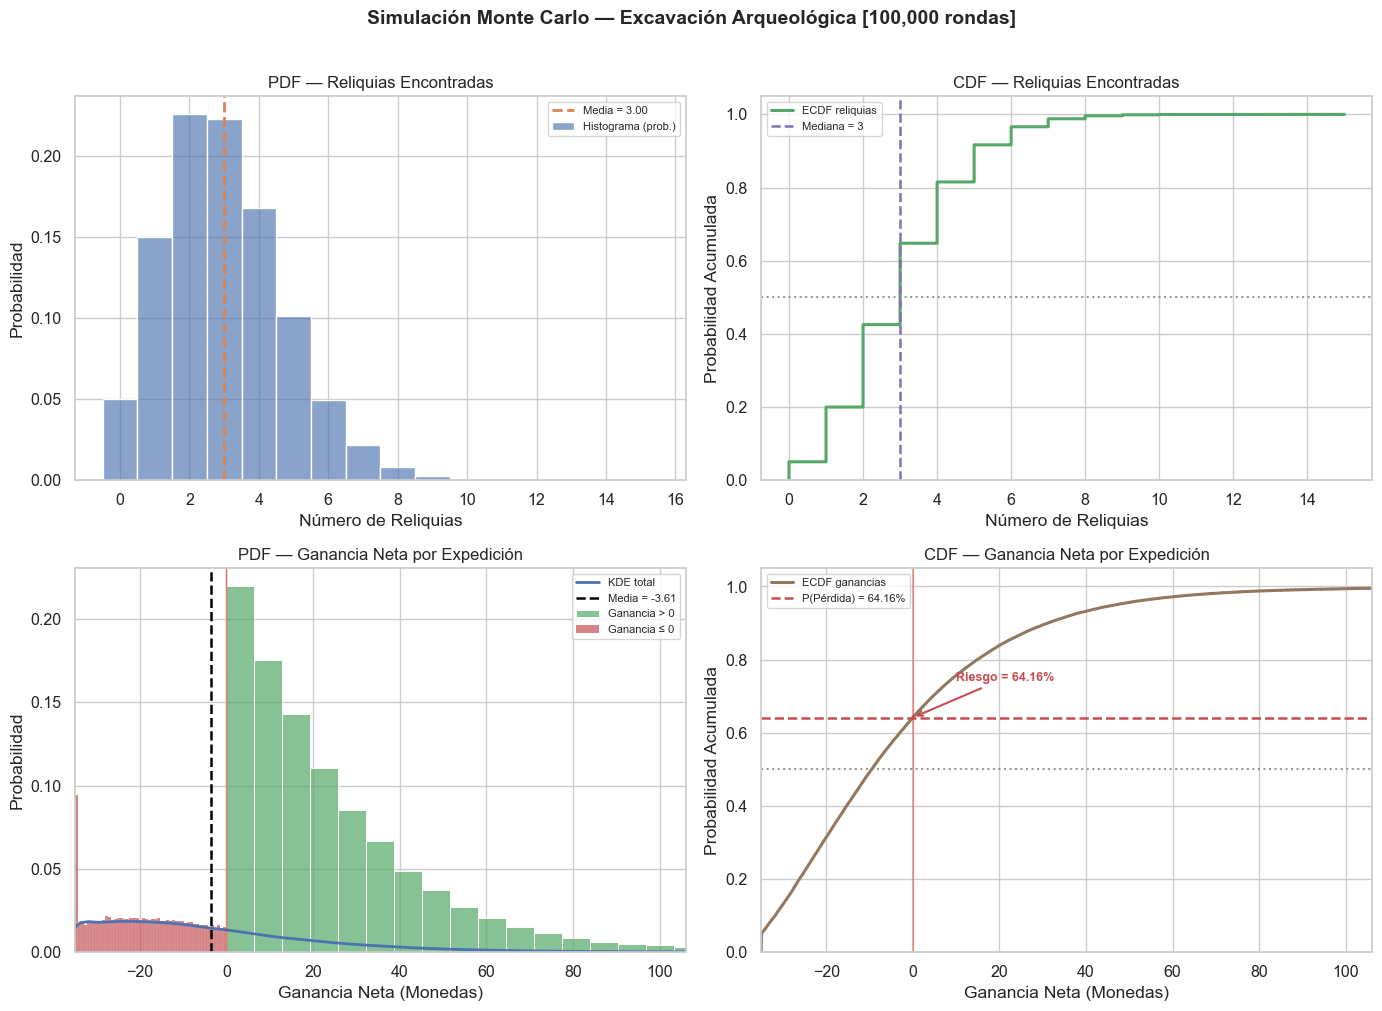

In [14]:
graficar_resultados(reliquias, ganancias_netas, NUM_RONDAS, KDE=False)

In [15]:
interact(
    dashboard_interactivo_jupyter,
    tasa_reliquias=FloatSlider(value=3.0, min=1.0, max=8.0, step=0.5, description='λ Reliquias:'),
    peso_medio=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5, description='Peso Medio:'),
    costo_expedicion=IntSlider(value=35, min=10, max=100, step=5, description='Costo Entrada:'),
    iteraciones=IntSlider(value=5000, min=1000, max=10000, step=1000, description='Iteraciones:'),
    KDE=IntSlider(value=False, min=False, max=True, step=1, description='KDE:'),
)

interactive(children=(FloatSlider(value=3.0, description='λ Reliquias:', max=8.0, min=1.0, step=0.5), FloatSli…

<function __main__.dashboard_interactivo_jupyter(tasa_reliquias: float, peso_medio: float, costo_expedicion: float, iteraciones: int, KDE: bool) -> None>

### PDF — Reliquias Encontradas (Variable Discreta)

Aunque la llamamos PDF (Función de Densidad de Probabilidad) por convención en librerías de graficación, técnicamente es una **PMF (Función de Masa de Probabilidad)** porque no podemos encontrar "2.5 reliquias".

* **¿Qué estamos viendo?** Un gráfico de barras escalonado (histograma discreto) que muestra la frecuencia relativa de encontrar $0, 1, 2, 3 \dots$ reliquias.
* **Comportamiento matemático:** Esta gráfica sigue una **Distribución de Poisson** con $\lambda = 3$.
* **Hitos visuales en la gráfica:**
    * **Asimetría positiva:** La gráfica está sesgada hacia la derecha.
    * **El pico (Moda):** Verás que las barras más altas están en $X=2$ y $X=3$. La probabilidad de encontrar exactamente 2 o 3 reliquias es la más alta (aprox. 22.4% cada una).
    * **El cero:** Hay una probabilidad de aproximadamente $5\% \ (e^{-3})$ de no encontrar absolutamente nada ($X=0$). En la gráfica, esto se ve como una barra pequeña pero significativa en el origen.
    * **La cola:** A partir de 6 o 7 reliquias, la altura de las barras cae drásticamente. Encontrar 10 reliquias es un evento estadísticamente muy raro.

### PDF — Ganancia Neta por Expedición (Variable Continua)

Representa una **Distribución Compuesta** (una suma aleatoria de variables aleatorias) desplazada por el costo de entrada.

* **¿Qué estamos viendo?** Un histograma continuo que muestra el rango de dinero con el que el jugador termina la ronda (recompensa final menos los 35 de costo).
* **Comportamiento matemático:** Es el resultado de sumar $X$ variables Exponenciales (donde $X$ es de Poisson), multiplicar por una constante (el precio), aplicar un multiplicador de Bernoulli (el bono) y restar una constante (el costo).
* **Hitos visuales críticos en la gráfica:**
    * **El "Muro" de la Ruina:** Habrá un pico extremadamente alto exactamente en **-35 monedas**. Este es el peor escenario posible y ocurre cuando el jugador encuentra 0 reliquias. Representa la pérdida total del costo de expedición.
    * **El Punto de Equilibrio (Línea Cero):** El área bajo la curva a la izquierda del $0$ representa la probabilidad de perder dinero (aprox. 65%-70%). El área a la derecha representa la probabilidad de salir con ganancias.
    * **La Cola Larga (Fat Tail):** A diferencia de una curva de campana normal, esta gráfica se extiende largamente hacia la derecha. Esto se debe a la distribución Exponencial de los pesos (existe la posibilidad remota de sacar una reliquia de 15 kg) combinada con el bono del Ídolo de Oro que duplica todo, con este número de iteraciones ocurre con una frecuencia aproximada de 4.82 veces. Esta cola larga es lo que crea la ilusión de que el juego es "ganable" para el jugador.

Analizar las Funciones de Distribución Acumulada (CDF, por sus siglas en inglés) es fundamental en el diseño de juegos, ya que nos permite entender el **riesgo** y la **frecuencia de los escenarios** de forma mucho más directa que con las funciones de densidad (PDF).

Mientras que la PDF responde a la pregunta *"¿Qué tan probable es este evento exacto?"*, la CDF responde a la pregunta **"¿Qué tan probable es obtener este resultado O UNO PEOR?"**. Por eso, toda CDF siempre comienza en 0 (0%) y trepa inexorablemente hasta 1 (100%).

### CDF — Reliquias Encontradas (El motor del juego)

Dado que las reliquias son una variable **discreta** (solo puedes encontrar cantidades enteras enteras: 0, 1, 2, 3...), su gráfica acumulada tiene una forma muy particular.

* **Forma de escalera (Step Function):** No se observa una curva suave, sino escalones. La línea es horizontal entre los números enteros porque la probabilidad no se acumula (no puedes encontrar 2.5 reliquias), y luego da un "salto" vertical exactamente en cada número entero.
* **El primer salto ($X = 0$):** En el eje X (valor 0), la línea salta de 0 a aproximadamente **0.05 (5%)**. Esto se lee como: *Existe un 5% de probabilidad de encontrar 0 reliquias o menos*.
* **La Mediana:** La línea punteada indica dónde la gráfica cruza el umbral del 50% ($Y = 0.5$). En una distribución de Poisson con media de 3, la mediana también es 3. Si miras el escalón en $X = 3$, veremos que el valor acumulado en el eje Y alcanza aproximadamente el **64%**.
    * *Interpretación de diseño:* El 64% de los jugadores encontrarán entre 0 y 3 reliquias. Solo el 36% restante de los jugadores experimentará la emoción de encontrar 4 reliquias o más.

### CDF — Ganancia Neta por Expedición (El bolsillo del jugador)

Esta gráfica es el "veredicto final" del juego. Al combinar variables discretas, continuas y eventos de Bernoulli, crea una distribución mixta fascinante.

* **El "Escalón de la Ruina" en -35:** A diferencia de una curva continua normal, notarás que la gráfica empieza plana en 0 y de repente da un salto vertical exactamente en **-35 monedas**. ¿Por qué? Porque el 5% de las veces el jugador no encuentra reliquias, lo que resulta en una pérdida exacta e inamovible de sus 35 monedas de entrada.
* **El Umbral del Dolor (Cruce por X = 0):** Este es el punto más crítico para evaluar si el juego es atractivo. Buscamos el valor de Y donde la curva cruza la línea roja ($X = 0$).
    * La gráfica muestra (y la anotación del código lo confirma) que en $X = 0$, el eje Y está aproximadamente en **0.65 a 0.70 (65% - 70%)**.
    * *Interpretación matemática:* $P(\text{Ganancia} \le 0) = 0.65$. Hay un 65% de probabilidades de que el jugador pierda parte de su dinero, lo pierda todo, o apenas recupere su inversión.
    * *La otra cara de la moneda:* Si el 65% de las partidas terminan en pérdida, significa que solo el **35% terminan en ganancia**.
* **La curva asintótica (La esperanza del jugador):** Observa la parte derecha de la gráfica. A partir del punto de equilibrio (0), la curva sube lentamente y le cuesta mucho llegar al 1.0 (100%).
    * *Interpretación de diseño:* Ese crecimiento lento significa que, aunque es raro ganar, cuando se gana, el premio puede variar enormemente (puedes ganar 10 monedas, pero también 80 o 150). Esta "cola" es impulsada por el multiplicador del 5% (el Ídolo de Oro) y es el gancho psicológico perfecto: la casa gana el 65% de las veces, pero el jugador sigue jugando buscando estar en ese pequeño porcentaje que alcanza el extremo derecho de la curva.

**En resumen:** La CDF de las reliquias te confirma que la mecánica base funciona como un reloj (sucesos constantes y predecibles), mientras que la CDF de las ganancias le demuestra al operador del casino que su negocio es seguro (riesgo de pérdida del jugador del ~65%), manteniendo suficiente volatilidad en la cola derecha para que el juego sea comercialmente exitoso.

### Tasa de victoria vs. Esperanza matemática (La ilusión del jugador)

* **Esperanza Matemática (El negocio de la casa):** Como demostramos, el juego tiene un Valor Esperado (EV) de **-3.5 monedas por ronda**. Esto equivale a un "margen de la casa" (*house edge*) exacto del **10%** sobre la apuesta inicial de 35 monedas. A largo plazo, por cada 10,000 partidas, el casino garantiza matemáticamente una ganancia de 35,000 monedas.
* **Tasa de victoria (El gancho del jugador):** La simulación arroja que el jugador termina con ganancias netas positivas (G > 0) aproximadamente entre el **30% y el 35% de las veces**.
* **Interpretación:** Ganar 1 de cada 3 partidas es una tasa de refuerzo psicológico excelente (similar a muchas máquinas tragamonedas de volatilidad media). El jugador siente que "casi" está empatando o que está en una racha, lo que lo motiva a seguir jugando. La disonancia entre ganar frecuentemente (35% de las veces) y perder dinero a largo plazo (EV negativo) es la piedra angular de un juego de azar rentable.

### Varianza y casos extremos (La tormenta perfecta)

La varianza del juego es intencionalmente alta, producto de la multiplicación de tres fuentes de incertidumbre independientes ($X \times W_i \times B$).

* **El efecto compuesto:** Para obtener un premio gigante ("El caso extremo"), el jugador necesita que los astros se alineen: sacar un valor alto en la Poisson (ej. 7 reliquias) **Y** que la Exponencial entregue pesos atípicos (ej. reliquias de 5 kg) **Y** acertar el 5% del Ídolo de Oro para duplicar.
* **Impacto de los cisnes negros:** Aunque la combinación anterior ocurre en menos del 0.1% de las partidas, esos casos extremos donde un jugador gana +250 monedas son fundamentales. En un entorno real (como un casino o un videojuego), esos son los momentos que los jugadores comparten, graban y recuerdan, actuando como publicidad gratuita para el juego. La alta varianza financia la narrativa de que "hacerse rico" es posible.